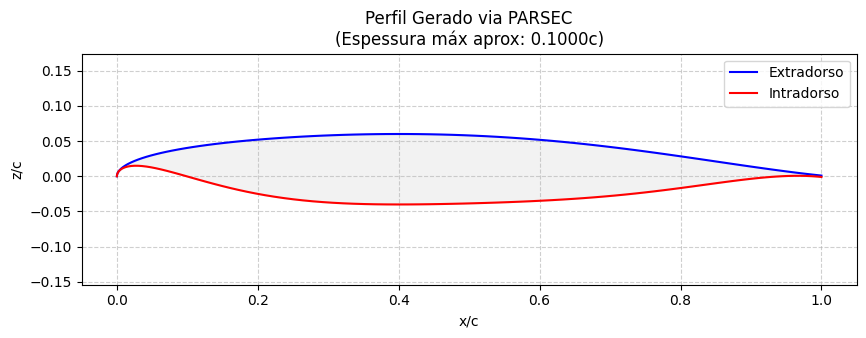

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def solve_parsec_coeffs(x_crest, z_crest, z_xx_crest, z_te, dz_te, alpha_te, r_le, surface='upper'):
    """
    Resolve os coeficientes an para uma superfície (superior ou inferior).
    Polinômio base: Z(x) = a1*x^0.5 + a2*x^1.5 + a3*x^2.5 + a4*x^3.5 + a5*x^4.5 + a6*x^5.5
    """
    
    # Definição das restrições geométricas
    # 1. Z(1) = Z_te +/- (dZ_te / 2)
    # 2. Z(x_crest) = z_crest
    # 3. dZ/dx(x_crest) = 0 (ponto de máximo/mínimo)
    # 4. d2Z/dx2(x_crest) = z_xx_crest (curvatura)
    # 5. Z(0) = 0 (bordo de ataque na origem) -> Implícito na forma do polinômio
    # 6. dZ/dx(0) -> Relacionado ao raio do bordo de ataque (r_le)
    
    # Ajuste de sinal e direção dependendo da superfície
    sign = 1 if surface == 'upper' else -1
    z_te_surf = z_te + sign * (dz_te / 2)
    beta_te = alpha_te # Simplificação: ângulo de saída
    
    # Montagem do sistema Ax = B
    # Coeficientes potências: 0.5, 1.5, 2.5, 3.5, 4.5, 5.5
    powers = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
    
    A = np.zeros((6, 6))
    B = np.zeros(6)
    
    # Eq 1: Z(x_crest) = z_crest
    A[0, :] = x_crest ** powers
    B[0] = z_crest
    
    # Eq 2: Z(1) = z_te_surf
    A[1, :] = 1.0 ** powers
    B[1] = z_te_surf
    
    # Eq 3: dZ/dx(x_crest) = 0
    A[2, :] = powers * (x_crest ** (powers - 1))
    B[2] = 0.0
    
    # Eq 4: d2Z/dx2(x_crest) = z_xx_crest
    A[3, :] = powers * (powers - 1) * (x_crest ** (powers - 2))
    B[3] = z_xx_crest
    
    # Eq 5: dZ/dx(1) = tan(beta_te - alpha_te) ... aproximado pela inclinação
    # Aqui usamos a tangente do ângulo de saída.
    # Ângulo em graus convertido para radianos
    A[4, :] = powers * (1.0 ** (powers - 1))
    B[4] = np.tan(np.radians(beta_te if surface == 'upper' else -beta_te)) 
    
    # Eq 6: Raio do bordo de ataque r_le
    # R_le = a1^2 / 2 => a1 = sqrt(2 * R_le)
    A[5, 0] = 1
    B[5] = np.sqrt(2 * r_le)
    
    # Resolver para os coeficientes [a1, a2, a3, a4, a5, a6]
    coeffs = np.linalg.solve(A, B)
    return coeffs, powers

def generate_parsec_coordinates(params, n_points=100):
    """
    Gera coordenadas X, Y baseado nos parâmetros PARSEC.
    """
    # Desempacotar parâmetros
    r_le = params['r_le']
    
    # Upper params
    x_up = params['x_up']
    z_up = params['z_up']
    z_xx_up = params['z_xx_up']
    
    # Lower params
    x_lo = params['x_lo']
    z_lo = params['z_lo']
    z_xx_lo = params['z_xx_lo']
    
    # Trailing edge params
    z_te = params['z_te']
    dz_te = params['dz_te']
    alpha_te = params['alpha_te']
    beta_te = params['beta_te']
    
    # Resolver coeficientes
    coeffs_up, pows = solve_parsec_coeffs(x_up, z_up, z_xx_up, z_te, dz_te, alpha_te, r_le, 'upper')
    coeffs_lo, pows = solve_parsec_coeffs(x_lo, z_lo, z_xx_lo, z_te, dz_te, beta_te, r_le, 'lower')
    
    # Gerar pontos (distribuição cosseno para suavidade nas pontas)
    beta = np.linspace(0, np.pi, n_points)
    x = (1 - np.cos(beta)) / 2
    
    # Calcular Z para upper e lower
    z_upper = np.zeros_like(x)
    z_lower = np.zeros_like(x)
    
    for i, p in enumerate(pows):
        z_upper += coeffs_up[i] * (x ** p)
        z_lower += coeffs_lo[i] * (x ** p)
        
    return x, z_upper, z_lower

# --- Parâmetros de Entrada (Modifique aqui) ---
parsec_params = {
    'r_le': 0.01,       # Raio do bordo de ataque
    
    # Superfície Superior
    'x_up': 0.40,       # Posição X da crista superior
    'z_up': 0.06,       # Altura Z da crista superior (Espessura/2 aprox)
    'z_xx_up': -0.4,    # Curvatura na crista superior
    
    # Superfície Inferior
    'x_lo': 0.40,       # Posição X da crista inferior
    'z_lo': -0.04,      # Altura Z da crista inferior
    'z_xx_lo': 0.4,     # Curvatura na crista inferior
    
    # Bordo de Fuga
    'z_te': 0.0,        # Posição Z do bordo de fuga
    'dz_te': 0.002,     # Espessura do bordo de fuga
    'alpha_te': -6.0,   # Ângulo de saída superior (graus)
    'beta_te': 6.0      # Ângulo de saída inferior (graus)
}

# --- Execução ---
x, z_up, z_lo = generate_parsec_coordinates(parsec_params)

# --- Plotagem ---
plt.figure(figsize=(10, 3))
plt.plot(x, z_up, label='Extradorso', color='blue')
plt.plot(x, z_lo, label='Intradorso', color='red')
plt.fill_between(x, z_lo, z_up, color='gray', alpha=0.1)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title(f"Perfil Gerado via PARSEC\n(Espessura máx aprox: {max(z_up - z_lo):.4f}c)")
plt.xlabel("x/c")
plt.ylabel("z/c")
plt.legend()
plt.show()